# 🚀 Orqest Tutorial 1: Building Your First Modular Agent

Welcome to the world of **modular AI development**! This tutorial will guide you through creating a simple conversational agent using the Orqest framework.

---

## 🎯 What You'll Learn

By the end of this tutorial, you'll understand:
- How to build type-safe, modular agents
- Why Orqest's architecture is superior to traditional approaches
- How to create reusable, testable AI components

---

## 💡 Why Orqest's Approach is Powerful

Traditional AI applications often mix business logic, state management, and AI interactions in one place, making them hard to test, debug, and extend.

**Orqest solves this by providing:**

| Principle | Benefit |
|-----------|----------|
| **Separation of Concerns** | State, output formats, and agent logic are separate |
| **Type Safety** | Everything is strongly typed using Pydantic models |
| **Modularity** | Agents can be composed, extended, and reused |
| **Testability** | Each component can be tested independently |
| **Consistency** | Standardized patterns for all agents |

Let's see these principles in action! 👇

---

## 📦 Step 1: Import Required Libraries

We start by importing the essential components. Notice how **clean and minimal** these imports are - this is by design!

```python
# What we're importing:
# 📋 pydantic     → Data validation and type safety
# 🤖 BaseAgent    → Core abstraction for all Orqest agents
# 🔧 typing       → Type hints for better code quality
```

**💪 Why this is convenient:** You only need to import what you actually use, and the framework handles the complex orchestration behind the scenes.

In [1]:
from pydantic import BaseModel, Field
from typing import List, Dict, Any
from orqest.agents.base_agent import BaseAgent

---

## 🧠 Step 2: Define the State Model

The `MyState` class is the **memory** of your agent. In essence, it can store all conversation history and any other data your agent needs to remember.

### 🌟 Why This Design is Brilliant

| Feature | Traditional Approach | Orqest Approach |
|---------|---------------------|------------------|
| **State Storage** | Hidden variables, global state | Explicit, typed models |
| **Validation** | Manual checks, runtime errors | Automatic validation |
| **Debugging** | Hard to inspect state | Full visibility |
| **Testing** | Complex setup required | Easy mock states |
| **Persistence** | Custom serialization | Built-in JSON support |

### 🎁 Real-World Benefits

- **🔍 Debugging**: Inspect the exact state at any point
- **🧪 Testing**: Create specific states for unit tests
- **💾 Persistence**: Save conversations to resume later
- **🔄 Multi-turn**: Handle complex conversations naturally

In [10]:
class MyState(BaseModel):
    """The conversation state - our agent's memory.

    This class demonstrates Orqest's explicit state management philosophy.
    Everything is typed, validated, and serializable.
    """
    messages: List[Dict[str, Any]] = Field(
        description="Conversation messages with role and content",
        default_factory=list
    )

    def add_message(self, role: str, content: str) -> None:
        """Add a message to the conversation history.

        This method encapsulates message addition, ensuring consistency
        and making it easy to add validation or transformations later.

        Args:
            role: Either 'user' or 'assistant'
            content: The message content
        """
        self.messages.append({"role": role, "content": content})

    def get_latest_message(self) -> Dict[str, Any]:
        """Get the most recent message in the conversation."""
        return self.messages[-1] if self.messages else {"role": "system", "content": "No messages yet"}

---

## 📤 Step 3: Define the Output Format (Optional)

The `TextOutput` class defines a **structured response format**. While our agent will return the updated state directly, having structured output models is useful for other components that need specific data formats.

### 🎯 Why Structured Outputs Matter

```python
# Without structure (traditional):
response = "Paris"  # What type? What format? What fields?

# With structure (Orqest):
response = TextOutput(answer="Paris")  # Clear, typed, validated!
```

**Benefits:**
- ✅ **Predictable Results**: You always know what format you'll get back
- ✅ **Type Safety**: IDEs can autocomplete and catch errors at development time
- ✅ **Easy Integration**: Other components know exactly how to consume the output
- ✅ **Validation**: Pydantic ensures the output meets your requirements
- ✅ **Documentation**: The schema serves as living documentation

### 🔧 Extensibility Example

Want richer outputs? Just extend the model:

```python
class RichTextOutput(BaseModel):
    answer: str = Field(description="The main response")
    confidence: float = Field(description="Confidence score 0-1")
    sources: List[str] = Field(description="Information sources used")
    metadata: Dict[str, Any] = Field(description="Additional context")
```

**Note**: In this tutorial, our agent returns the state directly (`MyState`), but structured outputs are essential for building complex agent pipelines!

In [11]:
class TextOutput(BaseModel):
    """Simple text output format for structured responses.

    While our agent returns MyState directly, this demonstrates
    how to define structured output formats for other use cases.
    """
    answer: str = Field(
        description="The assistant's reply text",
        min_length=1  # Ensure we always get a non-empty response
    )

---

## 🤖 Step 4: Build Your Agent - The Heart of Modularity

The `MyAgent` class showcases Orqest's powerful agent architecture. Let's break down why this design is so effective:

### 🏗️ State-Centric Architecture

`BaseAgent[MyState]` means our agent:

| Feature | What You Get                                                         |
|---------|----------------------------------------------------------------------|
| **Direct State Returns** | Agent returns the updated state directly (after the postprocessing!) |
| **Type Safety** | The `[MyState]` ensures type consistency throughout                  |
| **Standard Lifecycle** | Hooks for pre/post processing                                        |
| **Error Handling** | Built-in retry logic and error recovery                              |
| **Async Support** | High-performance async/await patterns                                |

### ⚙️ Configuration-Driven Setup

The `__init__` method shows Orqest's **declarative philosophy**:

```python
super().__init__(
    agent_name="my_agent",      # 🏷️  Unique identifier for monitoring
    output_type=TextOutput,     # 🎯  The output_type in this context is related to the pydantic-ai library, which allows us to return the response in a structured way.
    system_prompt="...",        # 📝  Behavior specification
    retries=2                   # 🔄  Built-in resilience
)
```

**Why this rocks:**
- 🚫 **No boilerplate**: Framework handles the complex stuff
- 📋 **Declarative**: You describe what you want, not how to do it
- 🔄 **Consistent**: All agents follow the same patterns
- 🎯 **State-focused**: Perfect for conversational agents that maintain context

### 🎭 The Two-Method Pattern

Orqest separates **what to do** from **how to handle the result**:

1. **`_run_implementation`**: Core agent logic
2. **`_process_response_implementation`**: Result processing

**Benefits:**
- 🎯 **Single Responsibility**: Each method has one job
- 🧪 **Testable**: Test logic and processing separately
- 🔄 **Reusable**: Override just the part you need to change
- 🛠️ **Maintainable**: Easy to understand and modify

In [16]:
class MyAgent(BaseAgent[MyState]):
    """A simple conversational agent demonstrating Orqest patterns.

    This agent showcases:
    - Clean inheritance from BaseAgent with state-centric design
    - Direct state returns for conversational continuity
    - Separation of concerns in method design
    """

    def __init__(self):
        """Initialize the agent with configuration.

        Notice how declarative this is - we specify WHAT we want,
        not HOW to implement it. The output_type=TextOutput means
        this agent when passed to the pydantic-ai library will return the
        response in the structured way defined by the TextOutput class.
        """
        super().__init__(
            agent_name="my_agent",
            output_type=TextOutput,
            system_prompt="You are a helpful assistant that provides accurate, concise information about the world.",
            retries=2  # Built-in resilience!
        )

    async def _run_implementation(self, state: MyState, **kwargs) -> MyState:
        """
        🚀 Core agent logic - this is where the magic happens!

        Notice how clean this is:
        1. Extract relevant information from state
        2. Format it for the LLM
        3. Call the underlying LLM agent
        4. Process and return the updated state

        The BaseAgent handles all the complex orchestration.
        """
        # Build the user prompt from the latest message
        latest = state.get_latest_message()
        prompt = f"User's latest message: {latest['content']}"

        # Call the LLM agent - BaseAgent handles retries, error handling, etc.
        response = await self.agent.run(prompt, **kwargs) # The response in this case is a TextOutput object. We still need to process it to update the state.

        # Process and update state using the framework's built-in method
        return await self._process_agent_response(response, state, **kwargs)

    async def _process_response_implementation(self, response: TextOutput, state: MyState, **kwargs) -> MyState:
        """
        🔄 Response processing - handles the agent's output gracefully.

        This pattern provides:
        - Direct state updates for conversational flow
        - Graceful fallbacks for parsing errors
        - State updates in a controlled manner
        - Consistent behavior across all agents
        """
        # Extract text content from the response
        if hasattr(response, "content"):
            content = response.content
        elif hasattr(response, "output") and hasattr(response.output, "answer"):
            content = response.output.answer
        else:
            content = str(response)

        # Add the assistant's response to the conversation
        state.add_message("assistant", content)

        # Return the updated state directly
        return state

---

## 🎬 Step 5: Run the Agent - See the Magic in Action

Now for the payoff! Let's see how elegantly everything comes together with the state-centric approach.

### ✨ The Three-Line Miracle

```python
state_demo = MyState()                                    # 1️⃣ Create initial state
state_demo.add_message(role="user", content="...")      # 2️⃣ Add user input
response_state = await agent.run(state_demo)             # 3️⃣ Get updated state back
```

### 🎭 What Happens Behind the Scenes

When you call `agent.run()`, Orqest automatically handles:

| Step | What Orqest Does |
|------|------------------|
| 1️⃣ | ✅ State validation and preprocessing |
| 2️⃣ | ✅ Agent lifecycle hooks execution |
| 3️⃣ | ✅ LLM interaction with retry logic |
| 4️⃣ | ✅ Response parsing and validation |
| 5️⃣ | ✅ State updates and post-processing |
| 6️⃣ | ✅ Error handling and logging |
| 7️⃣ | ✅ Return updated state with conversation history |

### 🌟 Why State-Centric Design is Revolutionary:
- **Conversational Continuity**: State flows naturally through the conversation
- **Simple Interface**: Complex operations become simple method calls
- **Reliable**: Built-in error handling and retries
- **Observable**: Full visibility into conversation history
- **Composable**: States can be passed between different agents
- **Scalable**: Framework handles the hard parts automatically

In [17]:
# Create a fresh conversation state
state_demo = MyState()
state_demo.add_message(role="user", content="What is the capital of France?")

# Instantiate and run the agent
agent = MyAgent()
response_state = await agent.run(state_demo)

# The result contains the full conversation history
response_state

MyState(messages=[{'role': 'user', 'content': 'What is the capital of France?'}, {'role': 'assistant', 'content': 'The capital of France is Paris.'}])

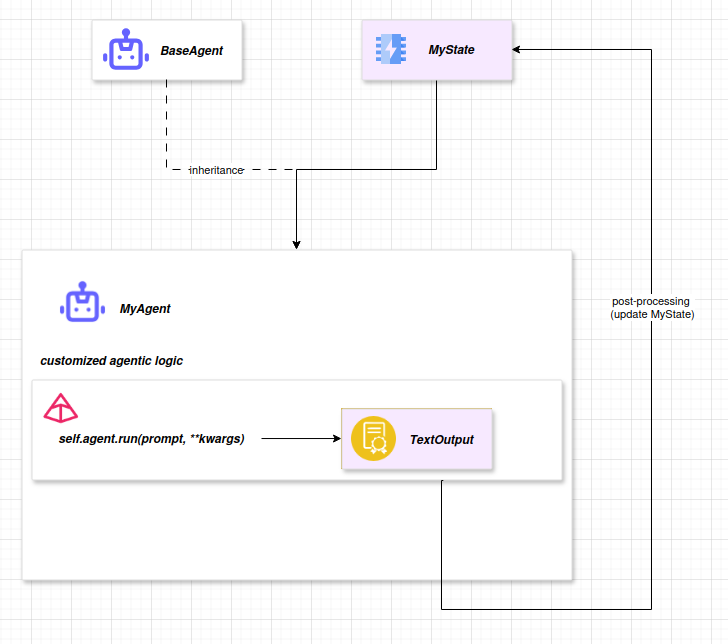
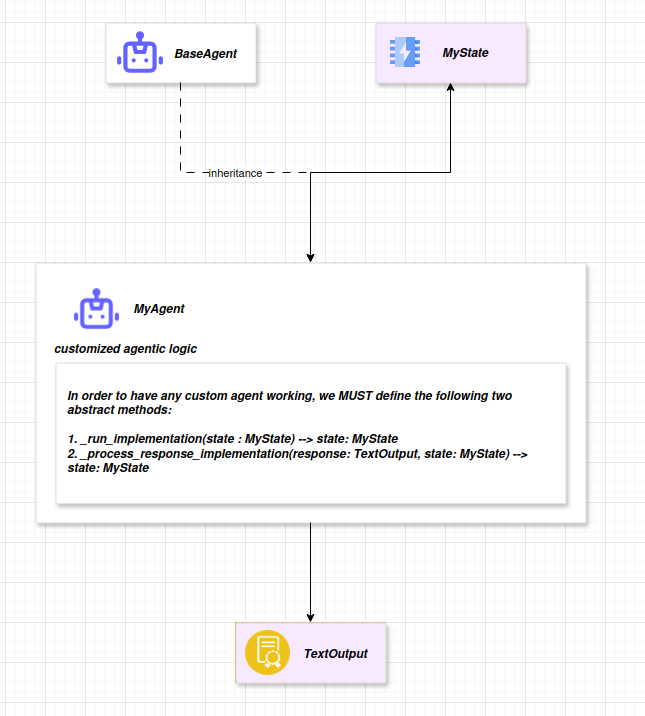
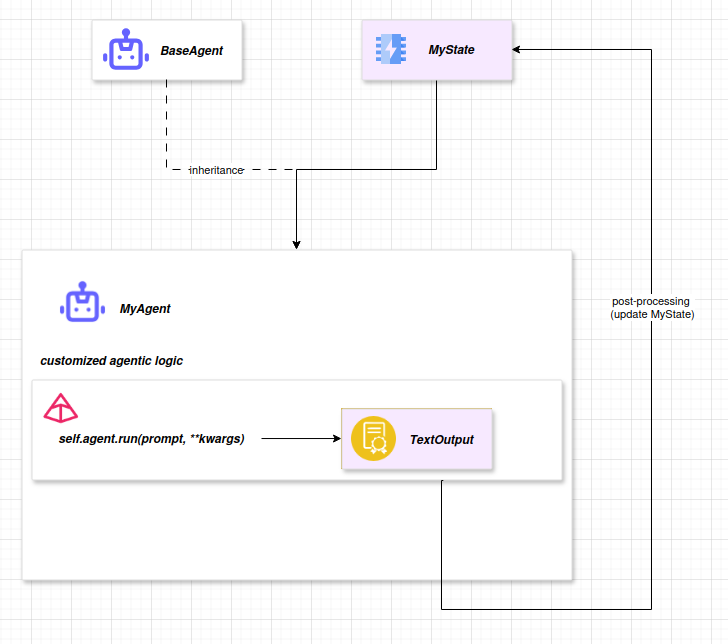

## 🎯 The Bigger Picture: Why State-Centric Architecture Wins

You've just experienced Orqest's state-centric philosophy in action. Let's understand why this approach is so powerful:

### 🔄 **Conversational Flow Made Simple**
```python
# Multi-turn conversation is natural:
state = MyState()
state.add_message("user", "What's the capital of France?")
state = await agent.run(state)  # State now has the response

state.add_message("user", "What's the population?")
state = await agent.run(state)  # Context is preserved automatically!
```

### 🧪 **Testing Made Simple**
```python
# Test with mock states
test_state = MyState()
test_state.add_message("user", "test input")
result = await agent.run(test_state)
assert len(result.messages) == 2  # User + assistant messages
assert result.messages[-1]["role"] == "assistant"
```

### 🔧 **Easy Extensions**
```python
# Add memory, tools, or complex reasoning:
class SmartAgent(MyAgent):
    async def _run_implementation(self, state: MyState, **kwargs) -> MyState:
        # Add your custom logic here
        enhanced_state = self.add_context_retrieval(state)
        return await super()._run_implementation(enhanced_state, **kwargs)
```

### 🏢 **Production Ready**
- **Monitoring**: Every agent has built-in logging and metrics
- **Resilience**: Automatic retries and error handling
- **Debugging**: Full state visibility at every step
- **Performance**: Async by default for high throughput
- **Persistence**: Save and restore conversation states easily

## 🚀 What's Next?

You've built a simple but powerful agent that demonstrates:
- ✅ Clean separation of concerns
- ✅ State-centric conversational flow
- ✅ Type-safe interactions
- ✅ Modular, reusable components
- ✅ Production-ready patterns

**Ready to go further?** Try:
1. Adding new fields to `MyState` (user preferences, context, etc.)
2. Building multi-agent conversations
3. Creating agent chains and workflows
4. Adding tools and external integrations
5. Implementing conversation branching and rollback

The patterns you've learned here scale from simple chatbots to complex AI systems. Welcome to the future of modular AI development! 🎉